# 1. Load the dataset




In [99]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,FireplaceYN_missing,PoolPrivateYN_missing,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,1,0,6500.0,33.475311,-117.708995,1500.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
1,1,0,1800000.0,33.899427,-117.977995,3546.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
2,1,0,1200000.0,34.095980,-118.221993,1162.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
3,1,1,3200.0,33.773119,-116.343788,1873.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,0,0,0,False,False,False,False,False,False,True
4,1,0,1425000.0,33.884526,-117.778002,1672.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204344,1,0,865000.0,34.242304,-116.802871,2166.0,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
204345,1,1,4000.0,33.701018,-116.292460,2957.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
204346,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,1,0,1,False,False,False,True,False,False,False
204347,0,0,595000.0,37.824500,-122.281570,2502.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False


 feature engineering

In [100]:
data_clean_2=data_clean.copy()
data_clean_2["BedBathRatio"]=data_clean_2["BedBathRatio"] = np.where(data_clean["BathroomsTotalInteger"] == 0,0, data_clean["BedroomsTotal"] / data_clean["BathroomsTotalInteger"])
data_clean_2["Years"]=2026-data_clean["YearBuilt"]

Adding more detailed geographic layer using school districts

In [101]:
import geopandas as gpd
districts=gpd.read_file('DistrictAreas2526_-284845464123469011.geojson')
districts_filter=districts[districts["DistrictType"]=="Unified"]
districts_filter

,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,932,2025-26,0641580,5772694,57726940000000,Yolo,Washington Unified,Unified,PK,12,...,1,0.0,1242,15.1,3796,46.2,27.524200,13,"13 - City, Small","POLYGON ((-13538678.161 4660316.003, -13538674..."
927,933,2025-26,0642930,5772702,57727020000000,Yolo,Winters Joint Unified,Unified,PK,12,...,105,5.0,335,16.0,1185,56.7,126.903010,31,"31 - Town, Fringe","POLYGON ((-13578206.161 4668467.848, -13577796..."
928,934,2025-26,0643080,5772710,57727100000000,Yolo,Woodland Joint Unified,Unified,PK,12,...,296,3.2,1704,18.3,6827,73.4,309.459071,23,"23 - Suburban, Small","POLYGON ((-13580837.089 4696906.449, -13580814..."
930,936,2025-26,0624090,5872736,58727360000000,Yuba,Marysville Joint Unified,Unified,PK,12,...,47,0.4,1673,16.0,7648,73.2,462.497708,22,"22 - Suburban, Midsize","POLYGON ((-13540500.026 4756982.131, -13540491..."


In [102]:
#points from the data
points=gpd.GeoDataFrame(data_clean_2,geometry=gpd.points_from_xy(data_clean_2["Longitude"],data_clean_2["Latitude"]), crs="EPSG:4326")
districts_filter = districts_filter.to_crs("EPSG:4326")
points=gpd.sjoin(points,districts_filter,how="left",predicate="within")#Left Join
points.drop(columns=["index_right","OBJECTID","FedID"])#drop unrelated feature

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,HOMpct,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc
0,1,0,6500.0,33.475311,-117.708995,1500.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,7.0,15.0,0.0,7174.0,15.5,16342.0,35.2,157.385389,21,"21 - Suburban, Large"
1,1,0,1800000.0,33.899427,-117.977995,3546.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,1200000.0,34.095980,-118.221993,1162.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,2.4,1294.0,0.3,81461.0,16.4,410978.0,82.7,699.955103,11,"11 - City, Large"
3,1,1,3200.0,33.773119,-116.343788,1873.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,10.8,13.0,0.1,2671.0,13.6,18133.0,92.4,496.440859,21,"21 - Suburban, Large"
4,1,0,1425000.0,33.884526,-117.778002,1672.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,13.9,15.0,0.1,3161.0,14.2,10492.0,47.1,39.259300,21,"21 - Suburban, Large"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204344,1,0,865000.0,34.242304,-116.802871,2166.0,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,10.3,4.0,0.2,330.0,15.3,1495.0,69.2,236.300524,32,"32 - Town, Distant"
204345,1,1,4000.0,33.701018,-116.292460,2957.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,2.3,131.0,0.5,3446.0,13.6,19324.0,76.5,768.026072,21,"21 - Suburban, Large"
204346,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,10.3,4.0,0.2,330.0,15.3,1495.0,69.2,236.300524,32,"32 - Town, Distant"
204347,0,0,595000.0,37.824500,-122.281570,2502.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,4.6,27.0,0.1,7646.0,17.6,34974.0,80.4,53.162702,11,"11 - City, Large"


# 2. Test train valid split¶

In [103]:
X=7 # past 2 month
months = sorted(points["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=points[points['date_ym'].isin(months[-X:-1])]
data_test=points[points['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

date_ym
2026-04-01    15657
2026-05-01    15615
2026-03-01    15077
2025-12-01    13478
2026-02-01    11879
2026-01-01    10756
Name: count, dtype: int64
date_ym
2026-06-01    16516
Name: count, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 82462 entries, 105371 to 187832
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           82462 non-null  int64   
 1   PoolPrivateYN                    82462 non-null  int64   
 2   ClosePrice                       82462 non-null  float64 
 3   Latitude                         82462 non-null  float64 
 4   Longitude                        82462 non-null  float64 
 5   LivingArea                       82462 non-null  float64 
 6   MLSAreaMajor                     82462 non-null  object  
 7   CountyOrParish                   82462 non-null  object  
 8   ParkingTotal                     82462 

In [104]:
data_test.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 16516 entries, 187833 to 204348
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           16516 non-null  int64   
 1   PoolPrivateYN                    16516 non-null  int64   
 2   ClosePrice                       16516 non-null  float64 
 3   Latitude                         16516 non-null  float64 
 4   Longitude                        16516 non-null  float64 
 5   LivingArea                       16516 non-null  float64 
 6   MLSAreaMajor                     16516 non-null  object  
 7   CountyOrParish                   16516 non-null  object  
 8   ParkingTotal                     16516 non-null  float64 
 9   PropertySubType                  16516 non-null  object  
 10  LotSizeAcres                     16516 non-null  float64 
 11  YearBuilt                        16516 non-null  float64 


In [105]:
lower=data_train["ClosePrice"].quantile(0.005)
upper=data_train["ClosePrice"].quantile(0.995)
data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

In [106]:
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [107]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

# 3. Train  Gradient Boosting model (XGBoost and LightGBM)

In [108]:
results = []

## 3.1 XGBoost

In [109]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

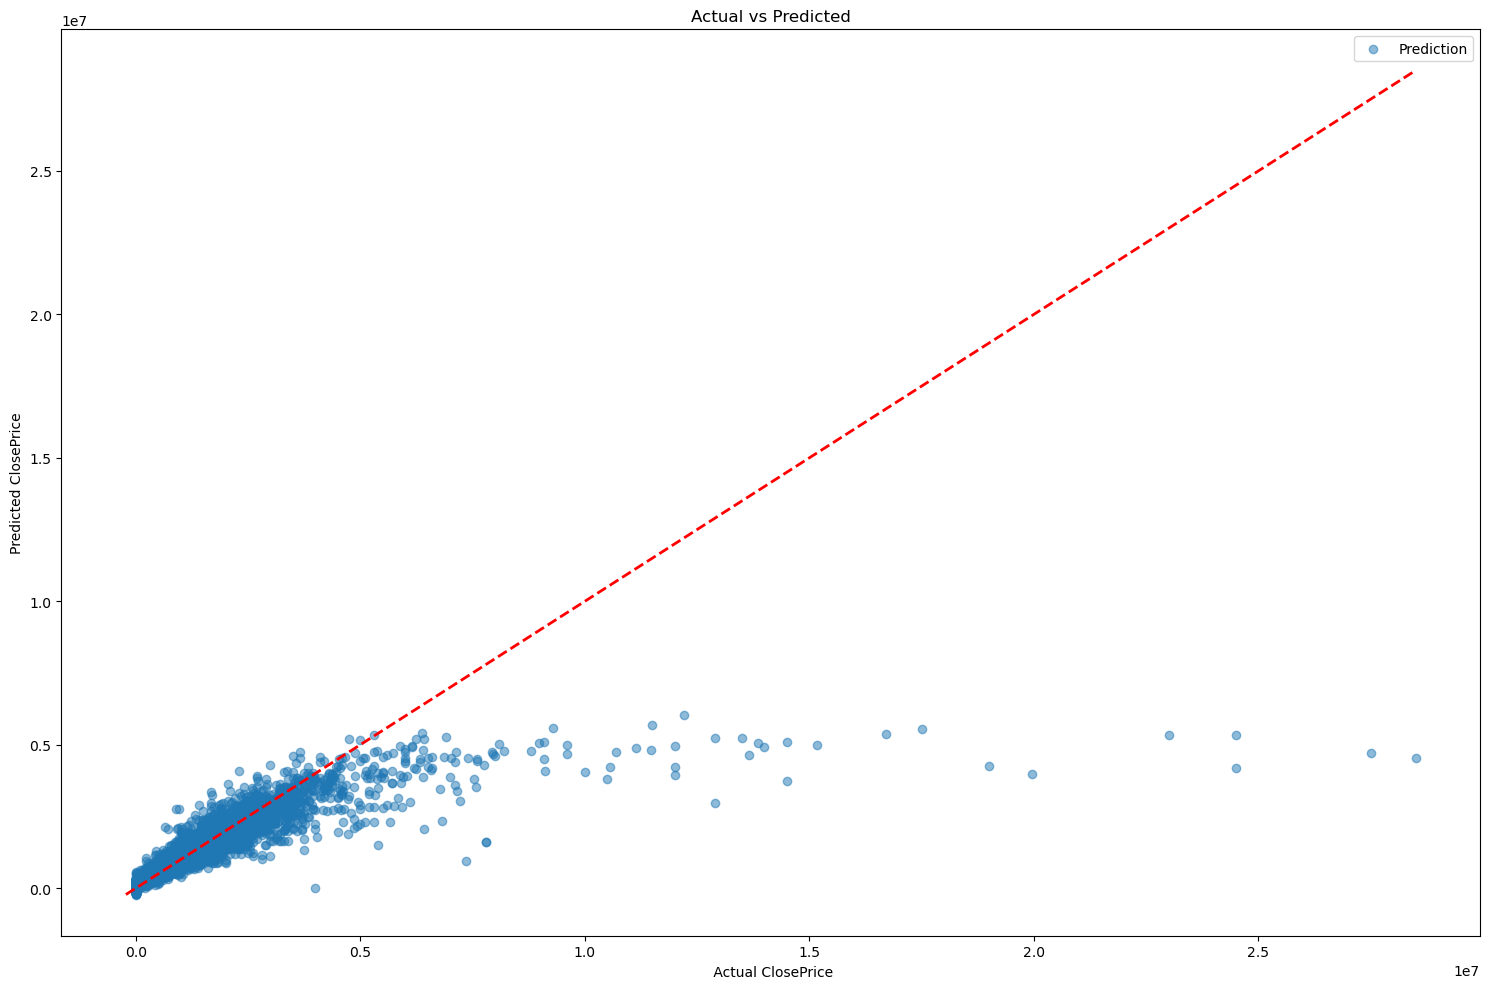

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel(" Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [111]:
print(model.score(X_train, y_train))

0.9269284471023617


In [112]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"XGBoost",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 15.09%
MAPE : 1.9523
R²   : 0.7017
MAE  : 157177.6818
MSE  : 351364538203.9146
RMSE : 592760.1017


## 3.2 LightGBM

In [113]:
import re

X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_test.columns
]

In [114]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7582
[LightGBM] [Info] Number of data points in the train set: 81642, number of used features: 122
[LightGBM] [Info] Start training from score 767378.542746
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

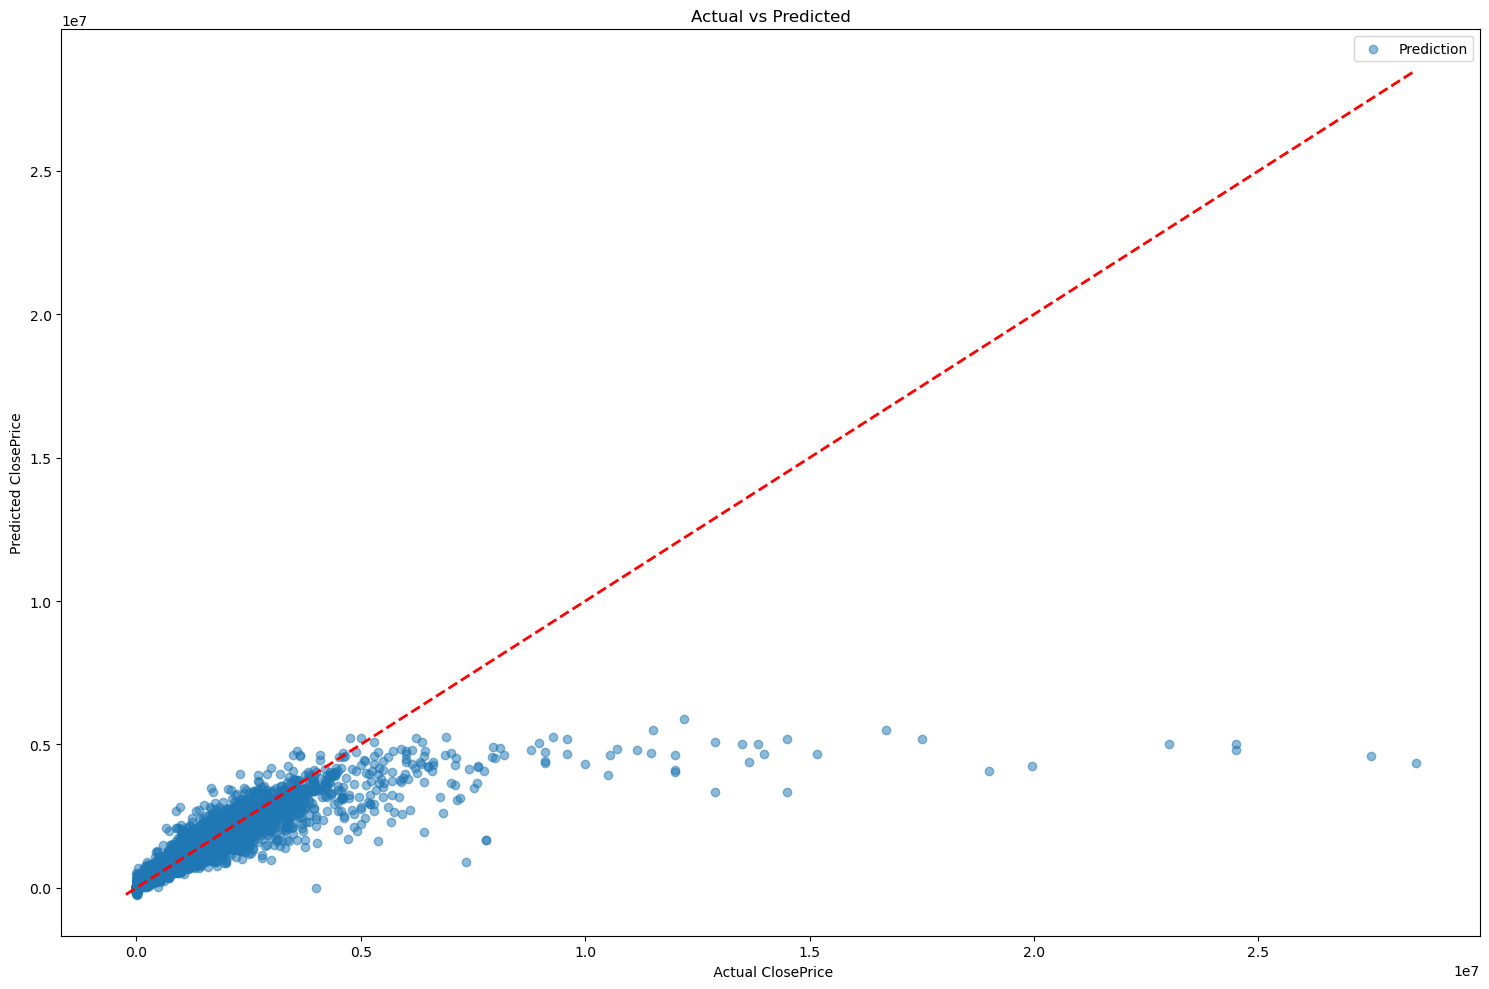

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel(" Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [116]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"LightGBM",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 15.73%
MAPE : 2.0439
R²   : 0.6952
MAE  : 161897.0692
MSE  : 358954869436.3651
RMSE : 599128.4248


In [117]:
print(model.score(X_train, y_train))

0.9139528219900721


# 4. Fine tuning the hyperparameters

# 4.1 LightGBM

In [118]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

def mdape(y_true, y_pred):
    ape = np.abs((y_true - y_pred) / y_true)
    return np.median(ape) * 100

mdape_scorer = make_scorer(
    mdape,
    greater_is_better=False  # 越小越好
)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "random_state": 42,
    }

    model = LGBMRegressor(**params)
    #score = cross_val_score(model, X_train, y_train,cv=5,scoring="r2").mean()
    score = cross_val_score(model, X_train, y_train,cv=5,scoring=mdape_scorer).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(study.best_params)

[I 2026-07-31 03:30:57,471] A new study created in memory with name: no-name-b84a960f-bdbd-4fbc-a9e5-cc7421f39e83


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7477
[LightGBM] [Info] Number of data points in the train set: 65313, number of used features: 121
[LightGBM] [Info] Start training from score 779771.325898
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

[I 2026-07-31 03:31:03,301] Trial 0 finished with value: -22.257563331910813 and parameters: {'n_estimators': 377, 'max_depth': 3, 'learning_rate': 0.029421212024810208}. Best is trial 0 with value: -22.257563331910813.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-07-31 03:31:15,788] Trial 1 finished with value: -17.517739636390974 and parameters: {'n_estimators': 302, 'max_depth': 10, 'learning_rate': 0.020689963910606082}. Best is trial 1 with value: -17.517739636390974.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015810 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7477
[LightGBM] [Info] Number of data points in the train set: 65313, number of used features: 121
[LightGBM] [Info] Start training from score 779771.325898
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083781 seconds.
You can set `force_row_

[I 2026-07-31 03:41:08,562] Trial 18 finished with value: -13.921295052853457 and parameters: {'n_estimators': 443, 'max_depth': 8, 'learning_rate': 0.14816406863137027}. Best is trial 18 with value: -13.921295052853457.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7477
[LightGBM] [Info] Number of data points in the train set: 65313, number of used features: 121
[LightGBM] [Info] Start training from score 779771.325898
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7468
[LightGBM] [Info] Number of data points in the train set: 65313, number of used features: 122
[LightGBM] [Info] Start training from score 775278.213202
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014860 seconds.
You can set `force_col_wise=true` to remove the overhead.
[Li

[I 2026-07-31 03:41:14,867] Trial 19 finished with value: -14.973548942787778 and parameters: {'n_estimators': 356, 'max_depth': 8, 'learning_rate': 0.06090626596004589}. Best is trial 18 with value: -13.921295052853457.


{'n_estimators': 443, 'max_depth': 8, 'learning_rate': 0.14816406863137027}


In [119]:
# Test： using best parameters
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=443,
    learning_rate=0.14816406863137027,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7582
[LightGBM] [Info] Number of data points in the train set: 81642, number of used features: 122
[LightGBM] [Info] Start training from score 767378.542746
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


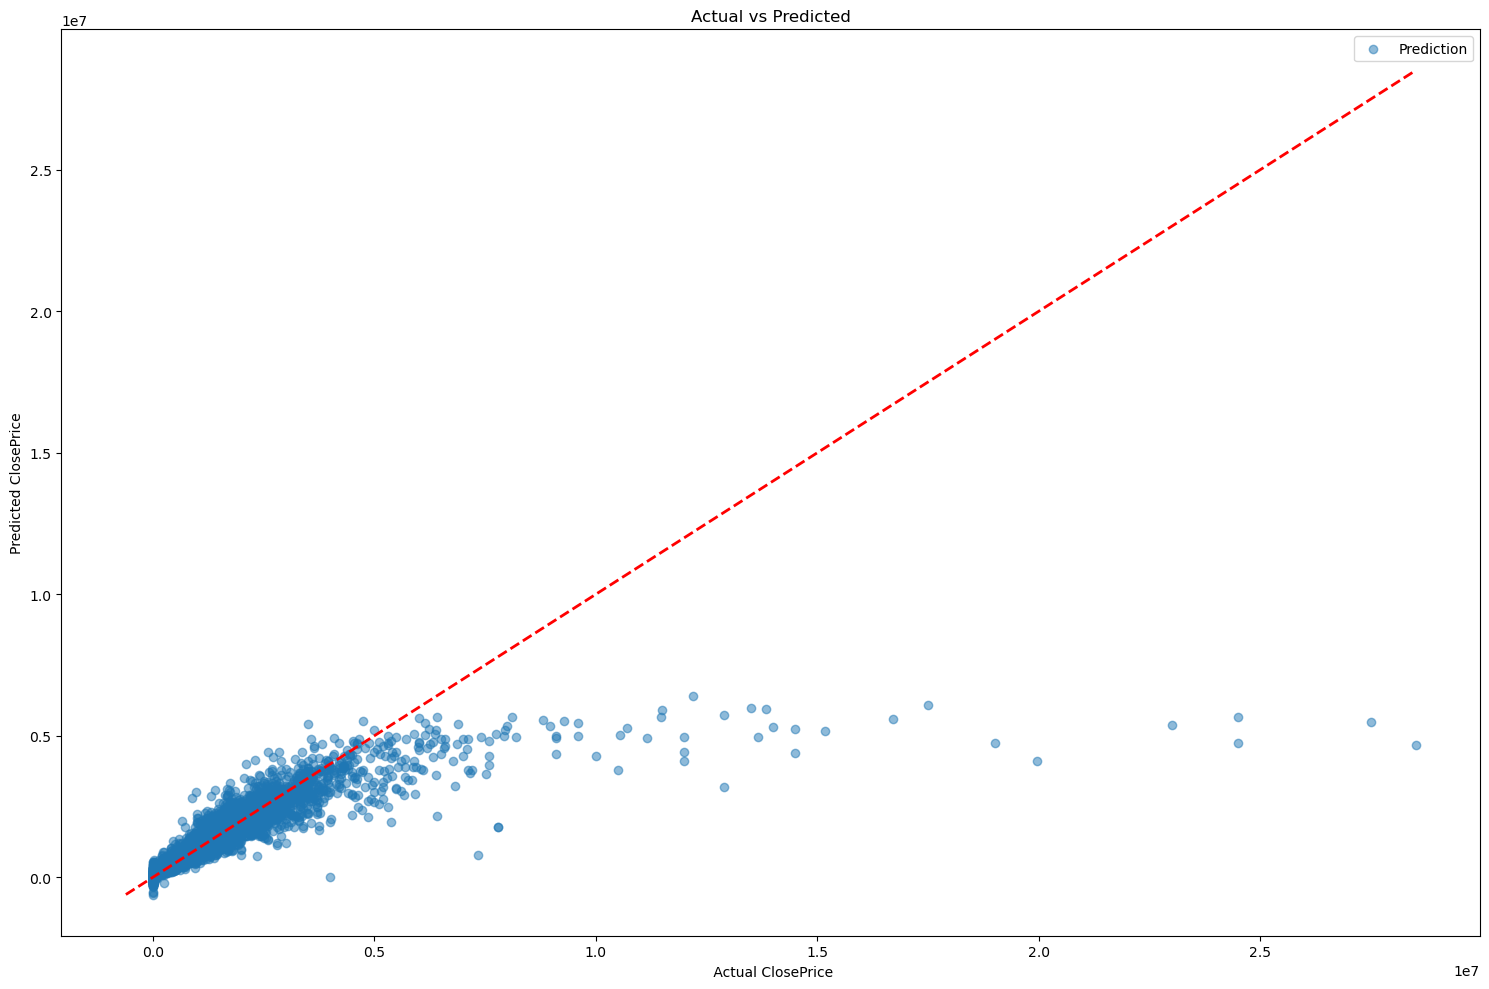

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel(" Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [121]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MdAPE: 13.46%
MAPE : 1.9905
R²   : 0.7243
MAE  : 146271.8223
MSE  : 324677208700.4532
RMSE : 569804.5355


## 4.2 XGBoost

In [122]:
import optuna
from sklearn.model_selection import cross_val_score
def mdape(y_true, y_pred):
    ape = np.abs((y_true - y_pred) / y_true)
    return np.median(ape) * 100

mdape_scorer = make_scorer(
    mdape,
    greater_is_better=False  # 越小越好
)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "random_state": 42,
        "subsample":0.8,
        "colsample_bytree":0.8,
        "random_state":42
    }

    model = XGBRegressor(**params)
    #score = cross_val_score(model, X_train, y_train,cv=5,scoring="r2").mean()
    score = cross_val_score(model, X_train, y_train,cv=5,scoring=mdape_scorer).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(study.best_params)

[I 2026-07-31 13:10:50,438] A new study created in memory with name: no-name-0e844d77-e7e7-4b11-9d2a-e1dfb919c7d6
[I 2026-07-31 13:10:57,324] Trial 0 finished with value: -29.02277032854642 and parameters: {'n_estimators': 218, 'max_depth': 4, 'learning_rate': 0.014749914395274167}. Best is trial 0 with value: -29.02277032854642.
[I 2026-07-31 13:11:03,529] Trial 1 finished with value: -20.52599608413767 and parameters: {'n_estimators': 286, 'max_depth': 3, 'learning_rate': 0.06981017417008849}. Best is trial 1 with value: -20.52599608413767.
[I 2026-07-31 13:11:25,888] Trial 2 finished with value: -35.45459847983985 and parameters: {'n_estimators': 202, 'max_depth': 3, 'learning_rate': 0.013791715286630625}. Best is trial 1 with value: -20.52599608413767.
[I 2026-07-31 13:12:14,404] Trial 3 finished with value: -12.412542621498632 and parameters: {'n_estimators': 326, 'max_depth': 10, 'learning_rate': 0.04322363435379801}. Best is trial 3 with value: -12.412542621498632.
[I 2026-07-31

{'n_estimators': 326, 'max_depth': 10, 'learning_rate': 0.04322363435379801}


In [123]:
# Test： using best parameters
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=326,
    learning_rate=0.04322363435379801,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

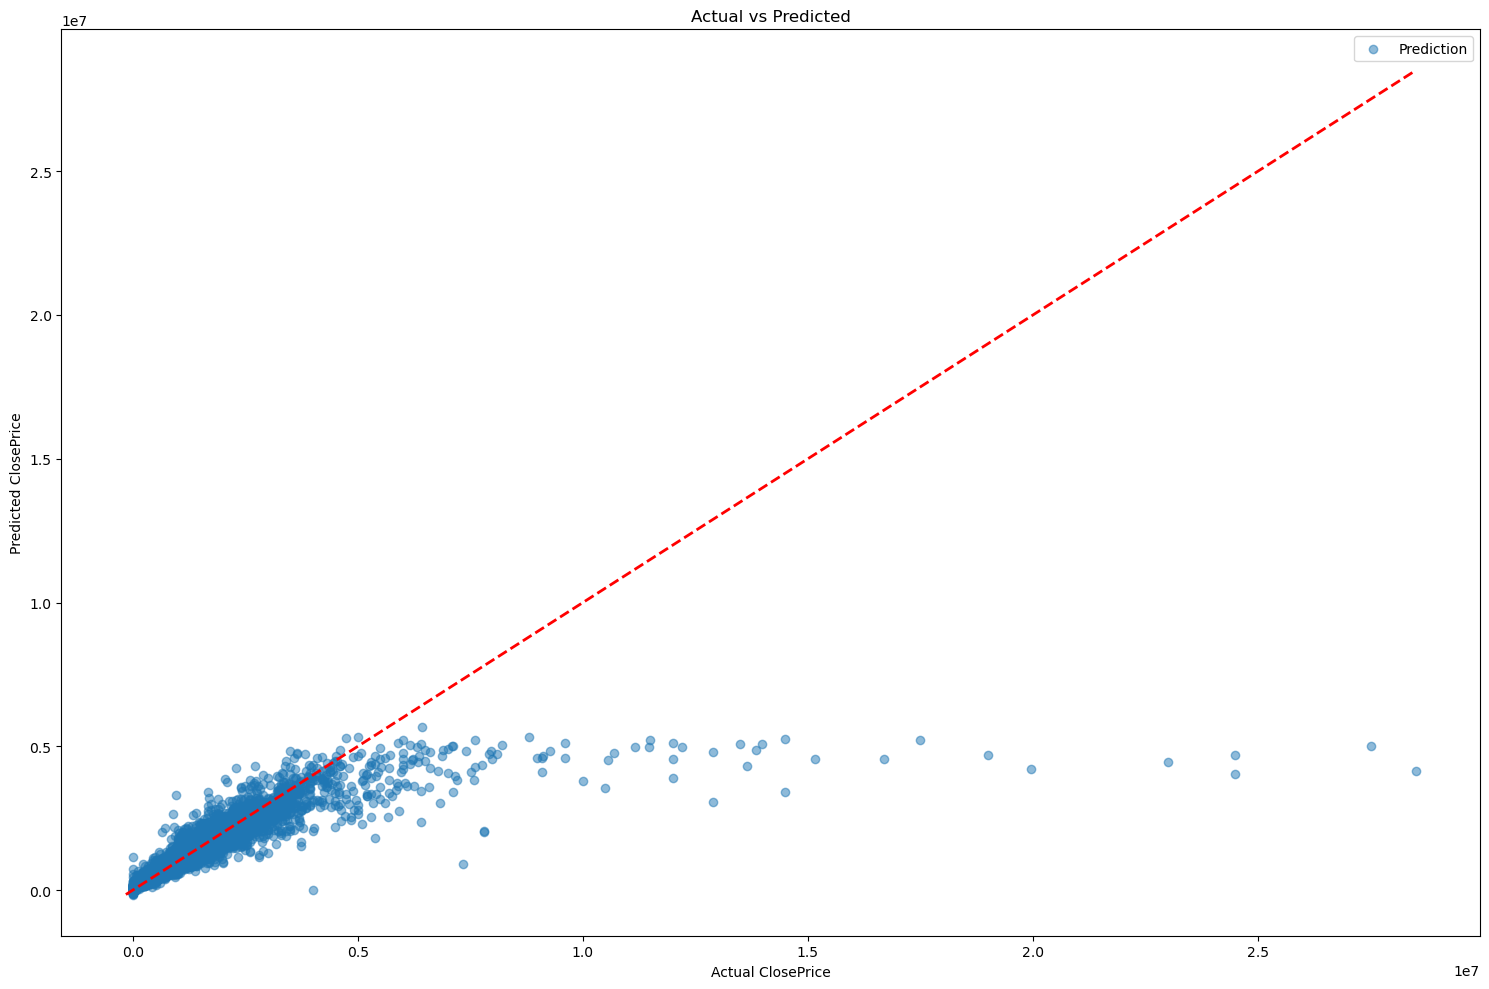

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [125]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MdAPE: 11.95%
MAPE : 0.9300
R²   : 0.7064
MAE  : 136998.6412
MSE  : 345779498296.8994
RMSE : 588030.1849
